# Mini Project Notebook: Employee Attrition Prediction
## PRASHANTH KANNADAGULI
### SENIOR DATA SCIENCE TRAINER

## Problem Statement

To predict employee attrition using CatBoost and XgBoost

## Learning Objectives

At the end of the experiment, you will be able to

* explore the employee attrition dataset
* apply CatBoost and XgBoost on the dataset
* tune the model hyperparameters to improve accuracy
* evaluate the model using suitable metrics


## Introduction

Employee attrition is the gradual reduction in employee numbers. Employee attrition happens when the size of your workforce diminishes over time. This means that employees are leaving faster than they are hired. Employee attrition happens when employees retire, resign, or simply aren't replaced.
Although employee attrition can be company-wide, it may also be confined to specific parts of a business.

Employee attrition can happen for several reasons. These include unhappiness about employee benefits or the pay structure, a lack of employee development opportunities, and even poor conditions in the workplace.

To know more about the factors that lead to employee attrition, refer [here](https://www.betterup.com/blog/employee-attrition#:~:text=Employee%20attrition%20is%20the%20gradual,or%20simply%20aren't%20replaced).


**Gradient Boosted Decision Trees**

* Gradient boosted decision trees (GBDTs) are one of the most important machine learning models.

* GBDTs originate from AdaBoost, an algorithm that ensembles weak learners and uses the majority vote, weighted by their individual accuracy, to solve binary classification problems. The weak learners in this case are decision trees with a single split, called decision stumps.

* Some of the widely used gradient boosted decision trees are XgBoost, CatBoost and LightGBM.

## Dataset

The dataset used for this mini-project is [HR Employee Attrition dataset](https://data.world/aaizemberg/hr-employee-attrition). This dataset is synthetically created by IBM data scientists. There are 35 features and 1470 records.

There are numerical features such as:

* Age
* DistanceFromHome
* EmployeeNumber
* PerformanceRating

There are several categorical features such as:
* JobRole
* EducationField
* Department
* BusinessTravel

Dependent or target feature is 'attrition' which has values as Yes/No.

### Install CatBoost

In [94]:
!pip -qq install catboost

### Import Required Packages

In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, metrics
import warnings
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 100)
%matplotlib inline

## Load the Dataset

**Exercise 1: Read the dataset**

**Hint:** pd.read_csv()

In [96]:
df = pd.read_csv("hr_employee_attrition_train.csv")

In [97]:
df.shape

(1170, 35)

There can be more than one file to read as this is introduced as a competition, dataset has one file for training the model. Their can be other files as one containing the test features and the other can be the true labels.

## Data Exploration

- Check for missing values
- Check for consistent data type across a feature
- Check for outliers or inconsistencies in data columns
- Check for correlated features
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships? Making correlation heatmaps makes it easy to identify possible collinearity

**Exercise 2: Create a `List` of numerical and categorical columns. Display a statistical description of the dataset. Remove missing values (if any)**

**Hint:** Use `for` to iterate through each column.

In [98]:
# Create lists of numerical and categorical columns
numerical_cols = []
categorical_cols = []

for column in df.columns:
    if df[column].dtype == "object":
        categorical_cols.append(column)
    else:
        numerical_cols.append(column)

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nStatistical description:")
display(df.describe(include="all").T)

print("\nMissing values:")
print(df.isnull().sum())

# Remove missing values, if any
df = df.dropna().copy()
print("\nShape after removing missing values:", df.shape)

Numerical columns:
['age', 'dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']

Categorical columns:
['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime', 'attrition']

Statistical description:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1170.0,NaN,NaN,NaN,36.85812,9.183448,18.0,30.0,35.0,43.0,60.0
businesstravel,1170,3,Travel_Rarely,831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dailyrate,1170.0,NaN,NaN,NaN,797.822222,403.592661,102.0,461.0,798.0,1146.75,1499.0
department,1170,3,Research & Development,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distancefromhome,1170.0,NaN,NaN,NaN,9.262393,8.150868,1.0,2.0,7.0,14.0,29.0
education,1170.0,NaN,NaN,NaN,2.917949,1.011534,1.0,2.0,3.0,4.0,5.0
educationfield,1170,6,Life Sciences,477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employeecount,1170.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
employeenumber,1170.0,NaN,NaN,NaN,1021.113675,600.548289,1.0,496.25,1008.5,1548.5,2065.0
environmentsatisfaction,1170.0,NaN,NaN,NaN,2.723932,1.095847,1.0,2.0,3.0,4.0,4.0



Missing values:
age                         0
businesstravel              0
dailyrate                   0
department                  0
distancefromhome            0
education                   0
educationfield              0
employeecount               0
employeenumber              0
environmentsatisfaction     0
gender                      0
hourlyrate                  0
jobinvolvement              0
joblevel                    0
jobrole                     0
jobsatisfaction             0
maritalstatus               0
monthlyincome               0
monthlyrate                 0
numcompaniesworked          0
over18                      0
overtime                    0
percentsalaryhike           0
performancerating           0
relationshipsatisfaction    0
standardhours               0
stockoptionlevel            0
totalworkingyears           0
trainingtimeslastyear       0
worklifebalance             0
yearsatcompany              0
yearsincurrentrole          0
yearssincelastpromotion

First, we want to get a sense of our data:
- What features have the most divergent distributions based on target class
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships, making correlation heatmaps makes it easy to identify possible colinearity

### Check for outliers

**Exercise 3: Create a box plot to check for outliers**

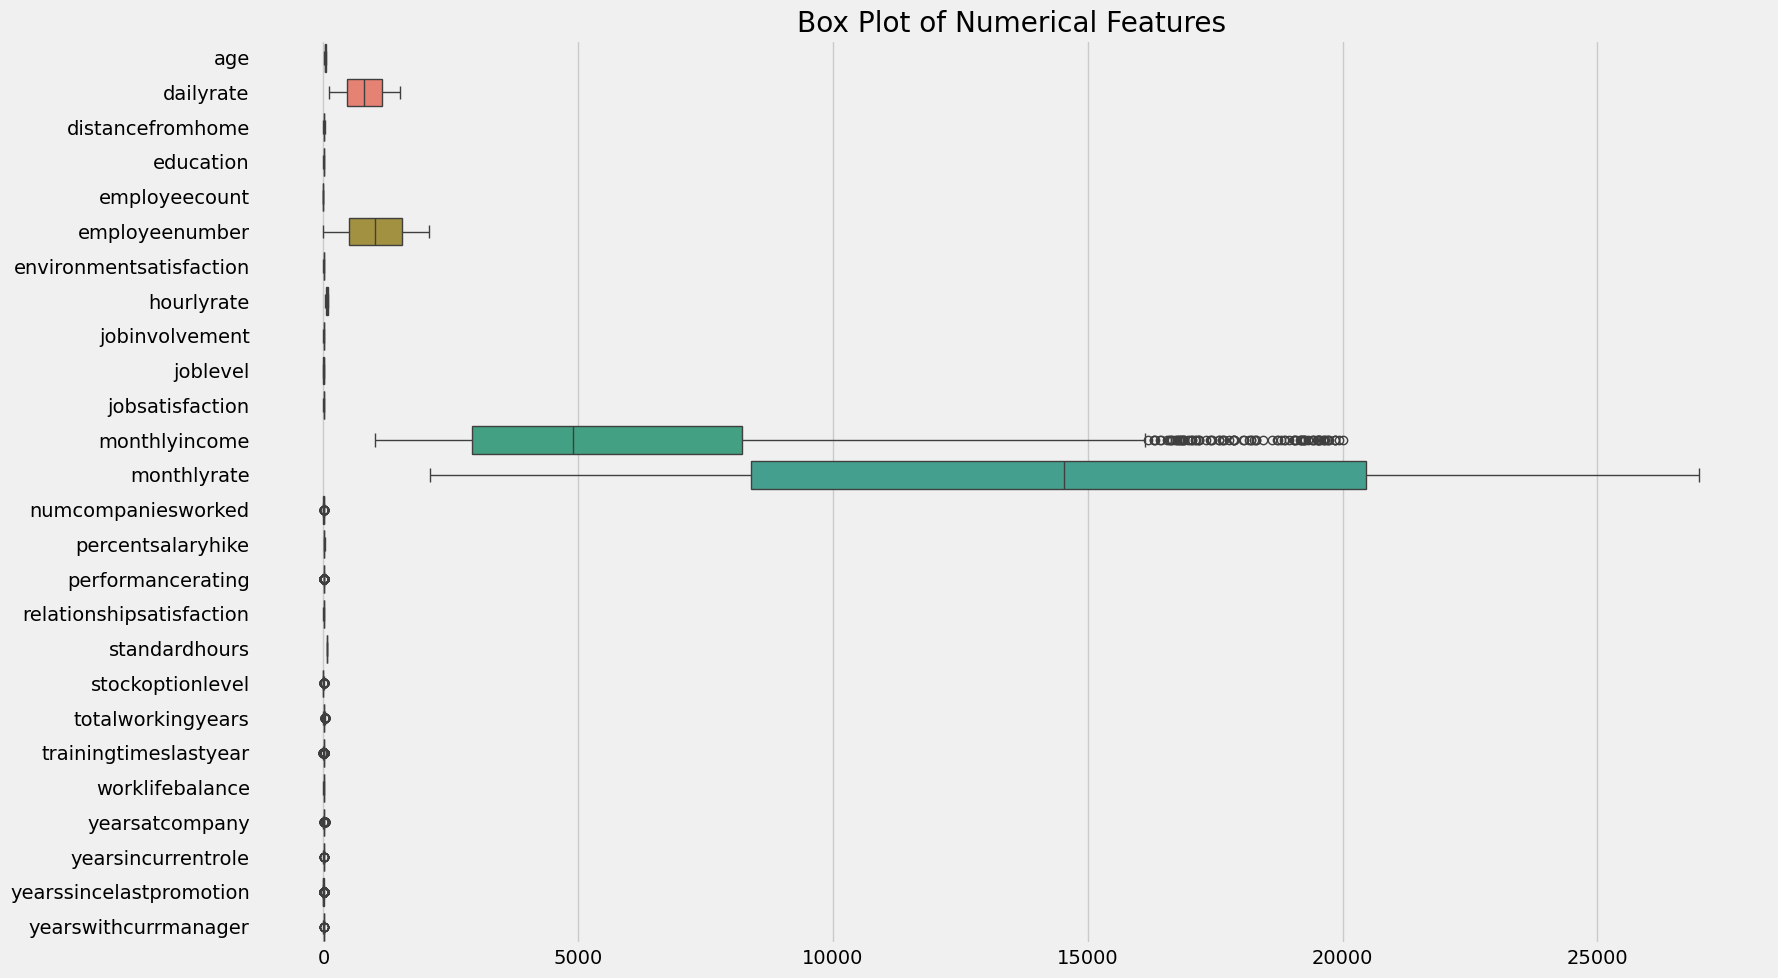

In [99]:
# Check for outliers using box plots for numerical features
plt.figure(figsize=(18, 10))
sns.boxplot(data=df[numerical_cols], orient="h")
plt.title("Box Plot of Numerical Features")
plt.tight_layout()
plt.show()

### Handling outliers

**Exercise 4: Use lower bound as 25% and upper bound as 75% to handle the outliers**

In [100]:
# Use Q1 (25%) as the lower bound and Q3 (75%) as the upper bound.
# Values outside these bounds are clipped to the corresponding quartile.
df_no_outliers = df.copy()

for column in numerical_cols:
    q1 = df_no_outliers[column].quantile(0.25)
    q3 = df_no_outliers[column].quantile(0.75)
    df_no_outliers[column] = df_no_outliers[column].clip(lower=q1, upper=q3)

print("Original shape:", df.shape)
print("Shape after outlier handling:", df_no_outliers.shape)

Original shape: (1170, 35)
Shape after outlier handling: (1170, 35)


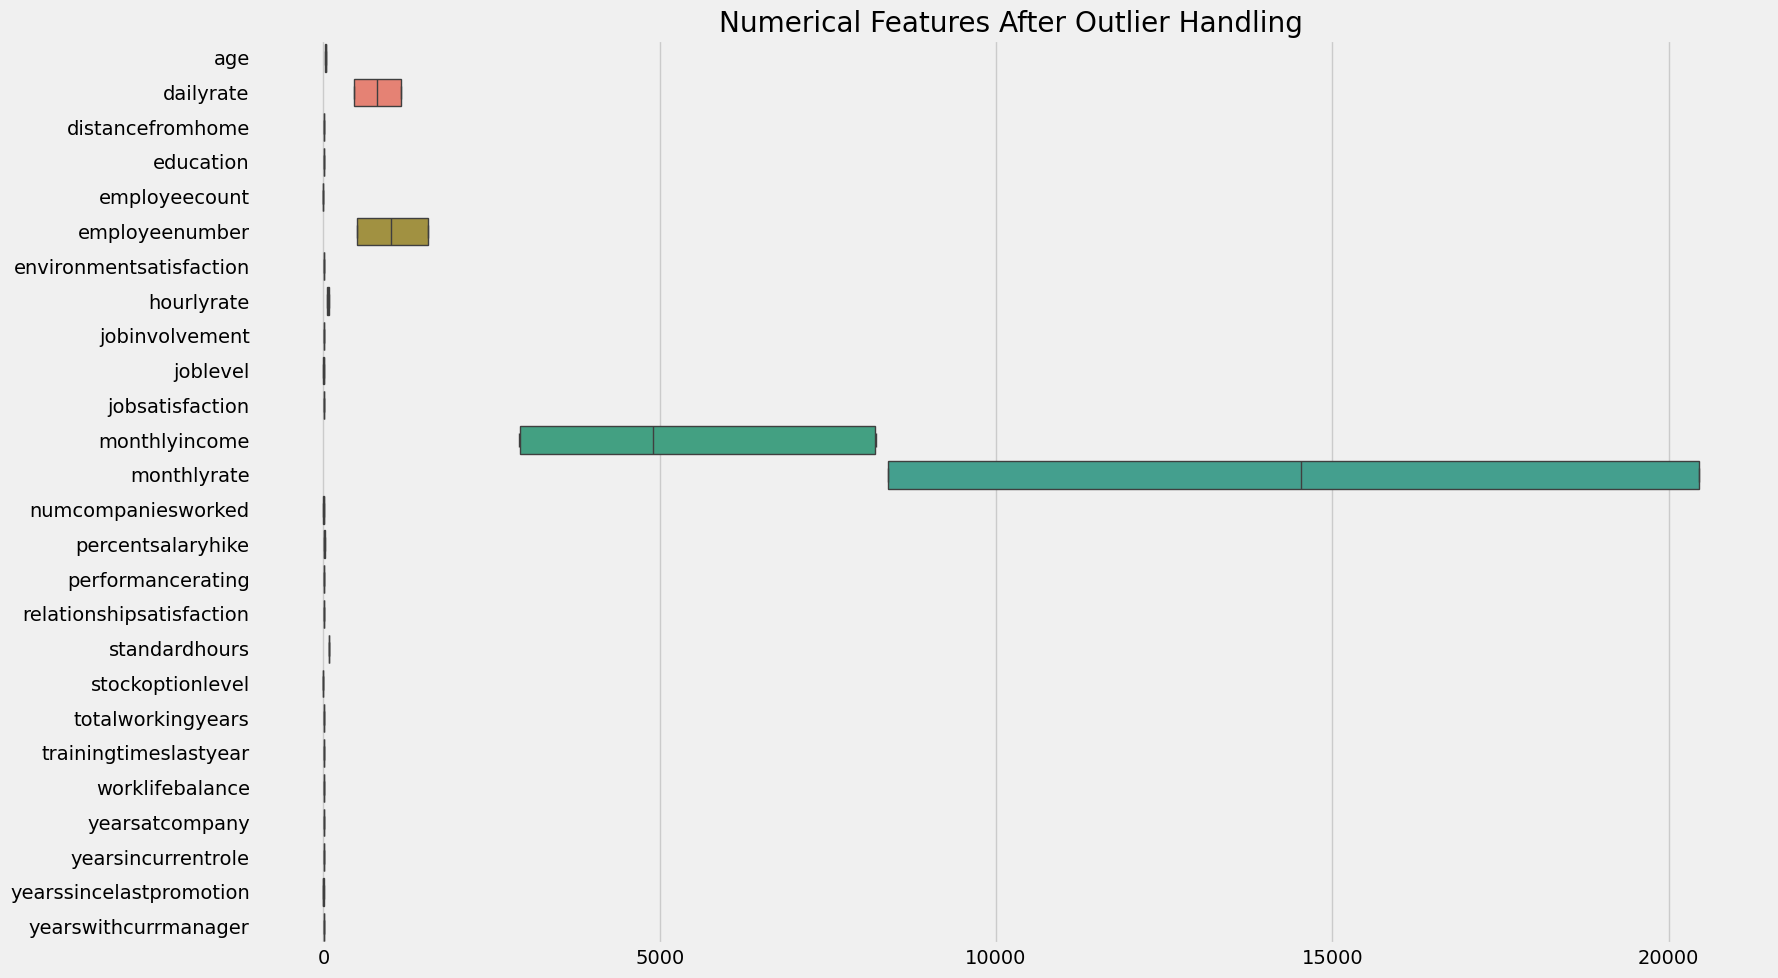

In [101]:
# Recheck for outliers after clipping
plt.figure(figsize=(18, 10))
sns.boxplot(data=df_no_outliers[numerical_cols], orient="h")
plt.title("Numerical Features After Outlier Handling")
plt.tight_layout()
plt.show()

### Target label imbalance

**Exercise 5: Check if there is an imbalance in target label**

**Hint:** Use value_counts()

In [102]:
# Count of unique values in Attrition column
df_no_outliers["attrition"].value_counts()

attrition
No     981
Yes    189
Name: count, dtype: int64

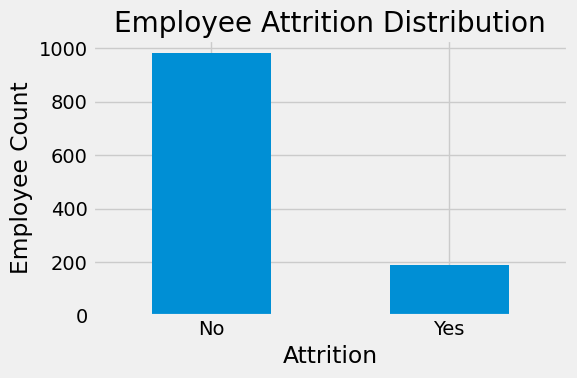

In [103]:
# Plot barplot to visualize balance/imbalance
attrition_counts = df_no_outliers["attrition"].value_counts()
ax = attrition_counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Employee Attrition Distribution")
ax.set_xlabel("Attrition")
ax.set_ylabel("Employee Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

If there is any imbalance in the dataset then a few techniques can be utilised (optional):
1. SMOTE
2. Cross Validation
3. Regularizing the model's parameters

###Plot pairplot

**Exercise 6: Visualize the relationships between the predictor variables and the target variable using a pairplot**

**Hint:** Use sns.pairplot

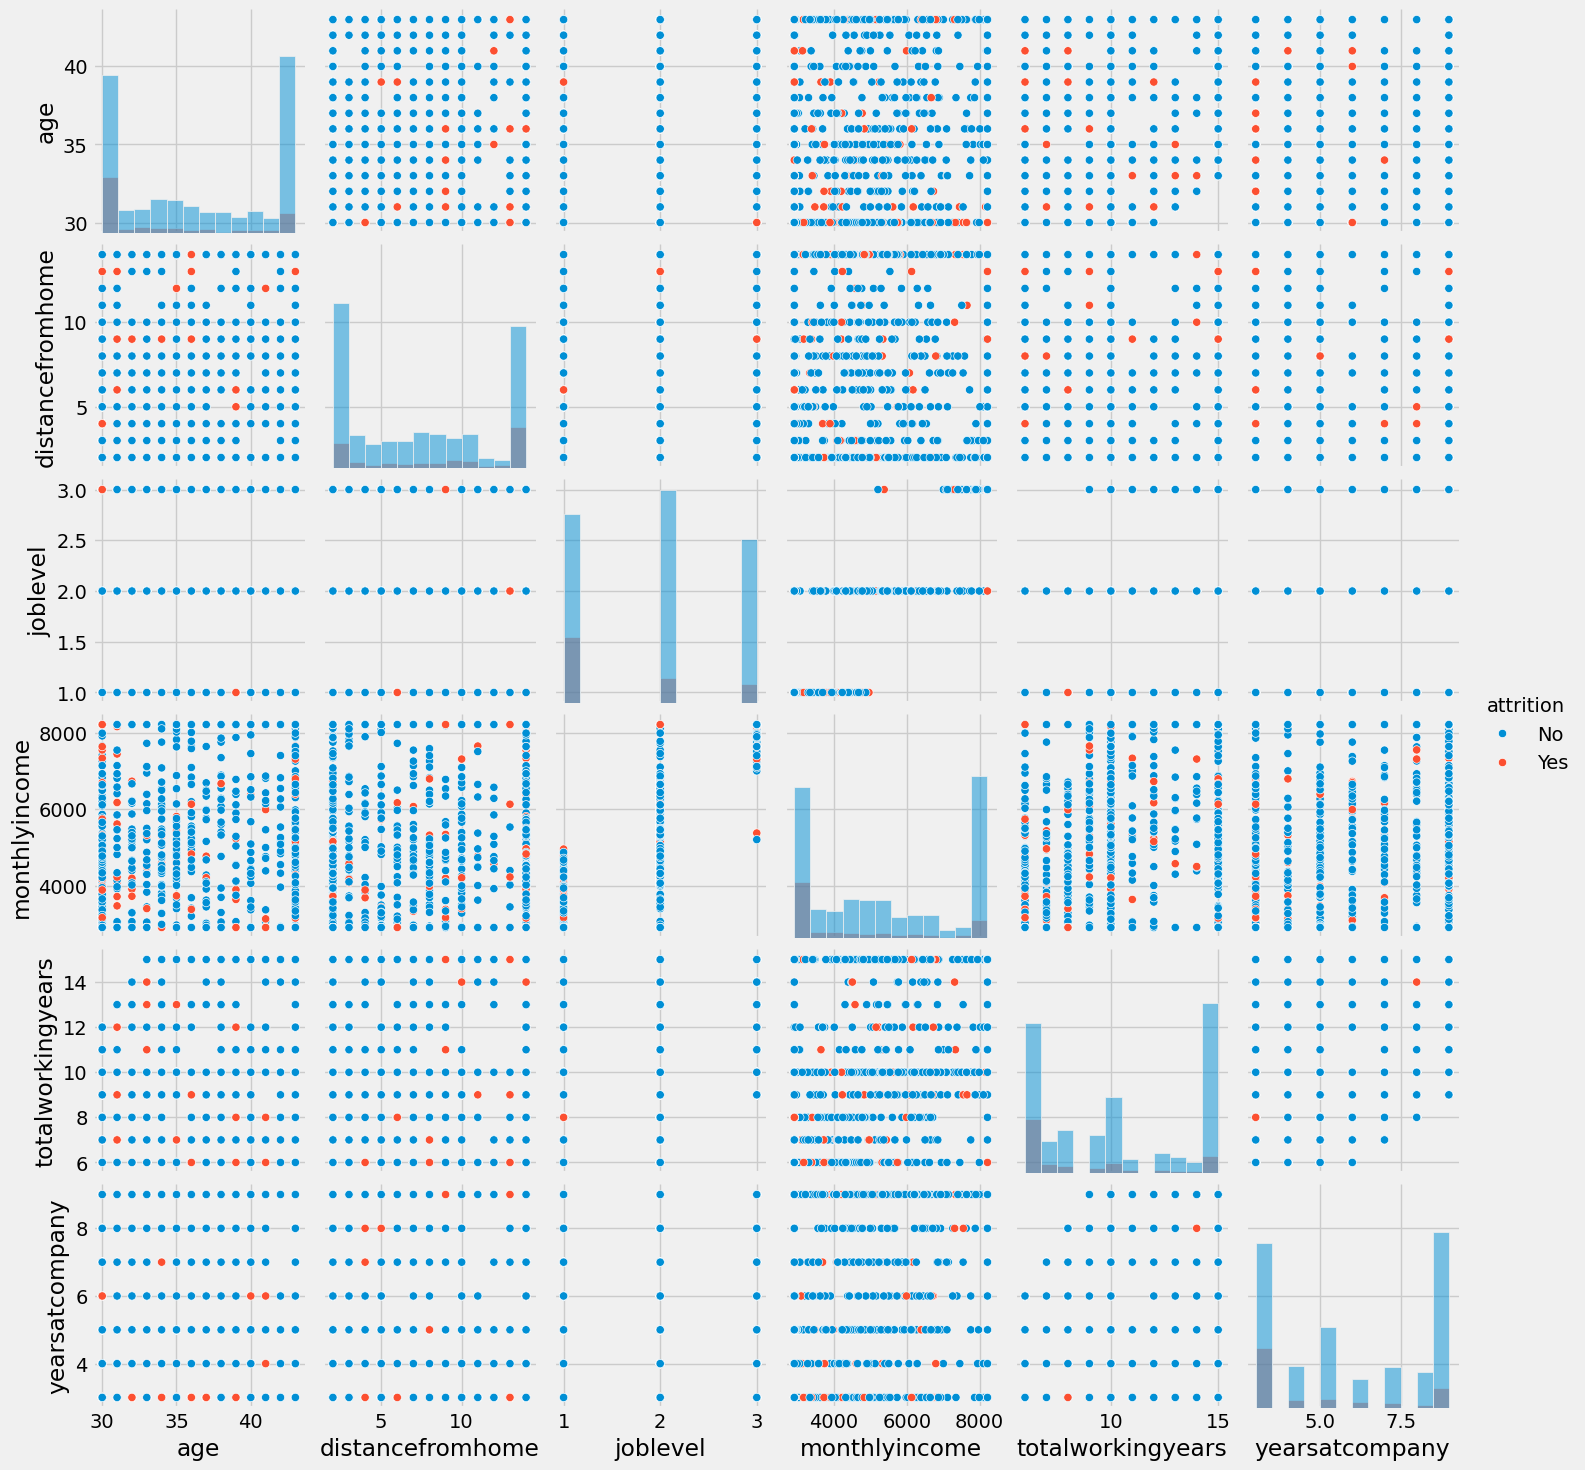

In [104]:
# Visualize a pairplot with relevant numerical features and the target
pairplot_cols = [
    "age", "distancefromhome", "joblevel",
    "monthlyincome", "totalworkingyears",
    "yearsatcompany", "attrition"
]

sns.pairplot(
    df_no_outliers[pairplot_cols],
    hue="attrition",
    diag_kind="hist"
)
plt.show()

### Explore Correlation

- Plotting the Heatmap

**Exercise 7: Visualize the correlation among IBM employee attrition numerical features using a heatmap**

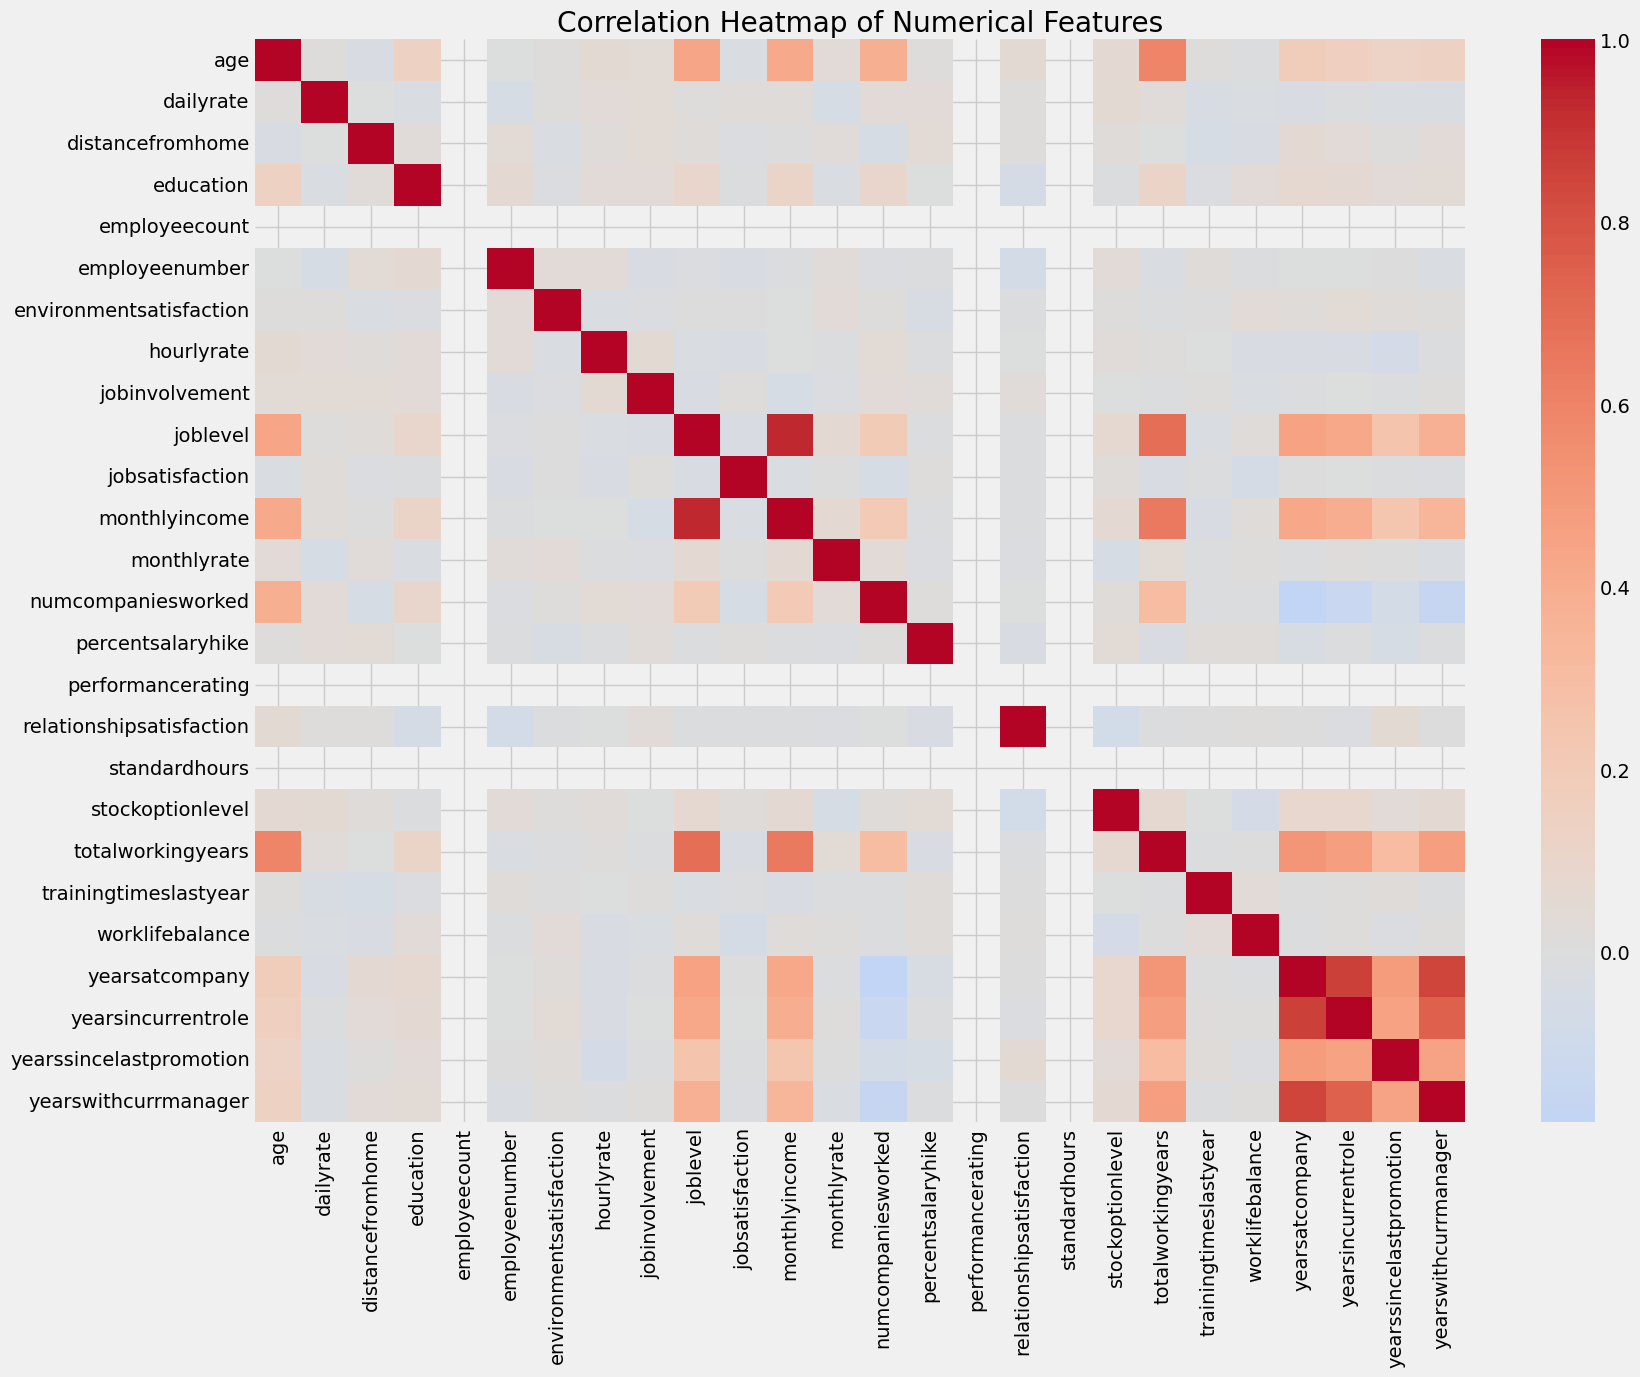

In [105]:
# Visualize heatmap
plt.figure(figsize=(18, 14))
corr = df_no_outliers[numerical_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

Comment on the observations made with the pairplot and heatmap

### Preparing the test feature space
* Remove outliers if any
* Handle the categorical feature if required
* Other processing steps can also be followed.

In [106]:
# Prepare the feature space
# The target is separated from the predictors.
X = df_no_outliers.drop(columns=["attrition"]).copy()
y = df_no_outliers["attrition"].map({"No": 0, "Yes": 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nCategorical features:", X.select_dtypes(include="object").columns.tolist())

Feature shape: (1170, 34)
Target shape: (1170,)

Categorical features: ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime']


Optional:
Use `Hyperopt`, a hyperparameter tuning technique to identify the best set of parameters.



In the notebook, data processing is done separately for different models.
Considering the fact that different models may require data in different format and in turn different processes may be followed to process the data.

If the processing steps followed for the models are same, data processing can also be done once.

## Apply CatBoost

Catboost was released in 2017 by Yandex, showing, by their benchmark to be faster in prediction, better in accuracy, and easier to use for categorical data across a series of GBDT tasks. Additional capabilities of catboost include plotting feature interactions and object (row) importance.

[Here](https://catboost.ai/en/docs/) is the official documentation of CatBoost

### Data Processing for CatBoost

**Exercise 8: Data processing for CatBoost**
* **Copy the dataframe that was created after removing the outliers**
* **Handle the categorical features if required**
* **Create target column and feature space**

**Hint:** Column containing the information on attrition will be the target column.

In [107]:
# Copy the data
cat_df = df_no_outliers.copy()

In [108]:
# Target Column
y_cat = cat_df["attrition"].map({"No": 0, "Yes": 1})

In [109]:
# Feature Space
X_cat = cat_df.drop(columns=["attrition"]).copy()

cat_features = X_cat.select_dtypes(include="object").columns.tolist()

print("Feature shape:", X_cat.shape)
print("Categorical features:", cat_features)

Feature shape: (1170, 34)
Categorical features: ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime']


### Model Definition

**Exercise 9: Define, train the model and display the results**

**Hint:**
* Use CatBoostClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model. Refer [here](https://catboost.ai/en/docs/concepts/speed-up-training) to see some ways to speedup CatBoost training.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [110]:
# Create CatBoost model
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

print(cat_model)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)


In [111]:
# Model training
X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat,
    y_cat,
    test_size=0.20,
    random_state=42,
    stratify=y_cat
)

cat_model.fit(
    X_cat_train,
    y_cat_train,
    cat_features=cat_features,
    eval_set=(X_cat_test, y_cat_test),
    early_stopping_rounds=50,
    verbose=False
)

print("CatBoost training completed.")

CatBoost training completed.


### Model performance

In [112]:
# Model performance on training and test sets
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    train_pred = model.predict(X_train).astype(int).ravel()
    test_pred = model.predict(X_test).astype(int).ravel()

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    metrics_row = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, train_prob),
        "Test ROC-AUC": roc_auc_score(y_test, test_prob)
    }

    print(f"\n{model_name}")
    print("Train Accuracy:", round(metrics_row["Train Accuracy"], 4))
    print("Test Accuracy :", round(metrics_row["Test Accuracy"], 4))
    print("Train F1      :", round(metrics_row["Train F1"], 4))
    print("Test F1       :", round(metrics_row["Test F1"], 4))
    print("Train ROC-AUC :", round(metrics_row["Train ROC-AUC"], 4))
    print("Test ROC-AUC  :", round(metrics_row["Test ROC-AUC"], 4))

    print("\nTest Confusion Matrix:")
    print(confusion_matrix(y_test, test_pred))

    return metrics_row

cat_results = evaluate_model(
    cat_model,
    X_cat_train, y_cat_train,
    X_cat_test, y_cat_test,
    "CatBoost"
)


CatBoost
Train Accuracy: 0.953
Test Accuracy : 0.859
Train F1      : 0.8321
Test F1       : 0.3529
Train ROC-AUC : 0.9948
Test ROC-AUC  : 0.7454

Test Confusion Matrix:
[[192   4]
 [ 29   9]]


## Apply XGBoost

XGBoost is a workhorse gradient boosted decision tree algorithm. Its been around since 2014 and has come to dominate the Kaggle and data science community. XGB introduced gradient boosting where new models are fit to the residuals of prior models and then added together, using a gradient descent algorithm to minimize the loss.

Read [here](https://xgboost.readthedocs.io/en/stable/parameter.html) on XGBoost parameters.

Refer [here](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) for the official documentation of XGBoost classifier.

### Data Processing for XGBoost


**Exercise 10: Data Processing for XGBoost**
* **Copy the dataframe after the outliers were removed.**
* **Handle the categorical features if required**
* **Create target column and feature space**

In [113]:
# Copy dataframe
xgb_df = df_no_outliers.copy()

**Hint:** Use pd.get_dummies

In [114]:
# Handling categorical features
# Encode only predictor categorical columns; keep the target column separate.
xgb_cat_cols = xgb_df.drop(columns=["attrition"]).select_dtypes(include="object").columns.tolist()

xgb_dummies = pd.get_dummies(
    xgb_df[xgb_cat_cols],
    drop_first=True,
    dtype=int
)

xgb_dummies.head()

,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes
0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0
3,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0
4,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0


In [115]:
# Concat the dummy variables to actual dataframe and remove initial categorical columns
xgb_df = pd.concat(
    [
        xgb_df.drop(columns=xgb_cat_cols),
        xgb_dummies
    ],
    axis=1
)

print("Shape after one-hot encoding:", xgb_df.shape)

Shape after one-hot encoding: (1170, 48)


When creating the dummy variables, the name of attrition column was changed, rename to 'attrition' again.

**Hint:** Use .rename

In [116]:
# Rename target column
# Convert Yes/No target to 1/0 and keep the name 'attrition'
xgb_df["attrition"] = xgb_df["attrition"].map({"No": 0, "Yes": 1})
xgb_df.head()

,age,dailyrate,distancefromhome,education,employeecount,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes
0,43,556.0,14,2,1,1548.50,2,83,2,2,4,5906.00,20456.25,1,13,3,4,80,1,10,2,2,9,7,2.75,7,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
1,34,970.0,8,2,1,757.00,2,83,3,2,3,6142.00,8387.50,3,12,3,4,80,0,10,2,3,5,2,2.75,3,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,39,461.0,14,3,1,1310.00,3,83,3,1,2,3904.00,20456.25,1,13,3,2,80,0,6,2,3,5,2,0.00,3,1,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0
3,30,933.0,2,3,1,496.25,3,57,3,2,3,5296.00,20156.00,1,17,3,2,80,1,8,3,3,8,7,2.75,7,0,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0
4,40,461.0,2,4,1,1361.00,2,83,3,1,2,2914.75,8387.50,3,18,3,3,80,1,7,3,3,4,2,0.00,3,0,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0


In [117]:
# Feature Space
X_xgb = xgb_df.drop(columns=["attrition"])

# Target label
y_xgb = xgb_df["attrition"]

print("Feature shape:", X_xgb.shape)
print("Target distribution:")
print(y_xgb.value_counts())

Feature shape: (1170, 47)
Target distribution:
attrition
0    981
1    189
Name: count, dtype: int64


### Model Definition

**Exercise 11: Define, train the model and display the results**

**Hint:**
* Use XGBClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [118]:
# Create XGBoost classifier model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [119]:
# Model training
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_xgb
)

xgb_model.fit(
    X_xgb_train,
    y_xgb_train,
    eval_set=[(X_xgb_test, y_xgb_test)],
    verbose=False
)

print("XGBoost training completed.")

XGBoost training completed.


### Model Performance

In [120]:
# Model performance on all sets
xgb_results = evaluate_model(
    xgb_model,
    X_xgb_train, y_xgb_train,
    X_xgb_test, y_xgb_test,
    "XGBoost"
)


XGBoost
Train Accuracy: 0.9989
Test Accuracy : 0.8803
Train F1      : 0.9967
Test F1       : 0.4815
Train ROC-AUC : 1.0
Test ROC-AUC  : 0.715

Test Confusion Matrix:
[[193   3]
 [ 25  13]]


## Apply LightGBM

LightGBM is an open-source GBDT framework created by Microsoft as a fast and scalable alternative to XGB and GBM. By default LightGBM will train a Gradient Boosted Decision Tree (GBDT), but it also supports random forests, Dropouts meet Multiple Additive Regression Trees (DART), and Gradient Based One-Side Sampling (Goss).

To know more about LightGBM parameters, refer [here](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier).

### Feature Engineering for LightGBM

In [121]:
# Following the same procedure as followed in XGBoost

# Copy the dataframe
lgb_df = df_no_outliers.copy()

# Handling categorical features
# Encode only predictor categorical columns; keep the target column separate.
lgb_cat_cols = lgb_df.drop(columns=["attrition"]).select_dtypes(include="object").columns.tolist()

lgb_dummies = pd.get_dummies(
    lgb_df[lgb_cat_cols],
    drop_first=True,
    dtype=int
)

# Concat the dummy variables to actual dataframe and remove initial categorical columns
lgb_df = pd.concat(
    [
        lgb_df.drop(columns=lgb_cat_cols),
        lgb_dummies
    ],
    axis=1
)

# Rename target column
lgb_df["attrition"] = lgb_df["attrition"].map({"No": 0, "Yes": 1})

# Features Space
X_lgb = lgb_df.drop(columns=["attrition"])

# Target Label
y_lgb = lgb_df["attrition"]

print("Feature shape:", X_lgb.shape)
print("Target distribution:")
print(y_lgb.value_counts())

Feature shape: (1170, 47)
Target distribution:
attrition
0    981
1    189
Name: count, dtype: int64


### Model Definition

**Hint:**
* Use LGBMClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [122]:
# Create LightGBM classifier model
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

print(lgb_model)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               random_state=42, subsample=0.8, verbosity=-1)


In [123]:
# Model training
X_lgb_train, X_lgb_test, y_lgb_train, y_lgb_test = train_test_split(
    X_lgb,
    y_lgb,
    test_size=0.20,
    random_state=42,
    stratify=y_lgb
)

lgb_model.fit(
    X_lgb_train,
    y_lgb_train
)

print("LightGBM training completed.")

LightGBM training completed.


### Model performance

In [124]:
# Model performance on all sets
lgb_results = evaluate_model(
    lgb_model,
    X_lgb_train, y_lgb_train,
    X_lgb_test, y_lgb_test,
    "LightGBM"
)


LightGBM
Train Accuracy: 1.0
Test Accuracy : 0.859
Train F1      : 1.0
Test F1       : 0.4
Train ROC-AUC : 1.0
Test ROC-AUC  : 0.6755

Test Confusion Matrix:
[[190   6]
 [ 27  11]]


## Results

**Exercise 12: Create a dataframe of XGBoost results and CatBoost results and display them**

**Hint:** Use pd.DataFrame

In [125]:
# Create a dataframe for computed metrics for different models
results_df = pd.DataFrame([
    cat_results,
    xgb_results,
    lgb_results
])

results_df.round(4)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,CatBoost,0.9530,0.8590,0.8321,0.3529,0.9948,0.7454
1,XGBoost,0.9989,0.8803,0.9967,0.4815,1.0000,0.7150
2,LightGBM,1.0000,0.8590,1.0000,0.4000,1.0000,0.6755


Reference reading:
1. https://machinelearningmastery.com/xgboost-for-imbalanced-classification/